# 04 — Hybrid Continuous Risk Scoring
## SIPEDULI — Sistem Pelaporan Kejahatan Terpadu

**Kenapa hybrid?**
- **Unsupervised (K-Means)** — generate label kontinu tanpa bias manual
- **Supervised (GradientBoostingRegressor)** — inference real-time pada teks baru
- Risk score kontinu lebih informatif dari label diskret (misal 89.3 vs sekadar "Tinggi")

**Hasil akhir pipeline ini:**

| Metrik | Nilai |
|--------|-------|
| Model | GradientBoostingRegressor (dipilih via PyCaret) |
| R² Test | **0.9045** |
| RMSE Test | 2.67 |
| MAE Test | 0.81 |
| Optuna Best CV RMSE | 1.78 (30 trials) |

**Alur pipeline:**
```
Dataset (2.413 baris berita kriminal)
  → 7 Urgency-Signal Features + StandardScaler
  → K-Means (k=3, n_init=30) → Critical Centroid → risk_score [0–100]
  → Feature Union: TF-IDF(3000) + 7 Urgency Scores → (n, 3007)
  → Optuna Tuning → GradientBoostingRegressor
  → model_final.pkl + vectorizer.pkl + model_metadata.json
```

## 0. Install Dependencies

## 1. Import & Konfigurasi

In [171]:
# ============================================================
# Import semua library yang dibutuhin di notebook ini.
# Dikelompokin biar gampang cari kalau ada yang kurang.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings
import json
from pathlib import Path

# Scikit-learn: clustering, scaling, evaluasi, vectorizer, split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# LightGBM: model regresi yang kita pakai
from lightgbm import LGBMRegressor

# Optuna: hyperparameter tuning otomatis
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────
# Cari root project secara otomatis dengan naik folder sampai ketemu folder 'data/'
# Trik ini supaya notebook bisa jalan dari mana aja, gak harus dari root
NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_PATH = ROOT / 'data' / 'dataset_siap_training.csv'
MODEL_DIR = ROOT / 'backend' / 'ml' / 'models'
DOCS_DIR  = ROOT / 'docs'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'ROOT      : {ROOT}')
print(f'DATA_PATH : {DATA_PATH}')
print(f'Ada file? : {DATA_PATH.exists()}')
print(f'MODEL_DIR : {MODEL_DIR}')

ROOT      : C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting
DATA_PATH : C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\data\dataset_siap_training.csv
Ada file? : True
MODEL_DIR : C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\backend\ml\models


## 2. Load & Filter Dataset

In [172]:
# ============================================================
# Load dataset dan filter data asli (is_synthetic == 'No').
#
# Kenapa hanya data asli?
# Data SMOTE itu data buatan hasil augmentasi statistik.
# Kalau kita pakai buat clustering, cluster yang terbentuk bisa
# bias karena SMOTE nggak nangkap nuansa semantik teks yang nyata.
# Jadi kita hanya pakai data real dari scraping berita kriminal.
# ============================================================

df_full = pd.read_csv(DATA_PATH)

print(f'Total semua data (termasuk SMOTE): {len(df_full):,} baris')
print(f'  - Data asli (is_synthetic=No)  : {(df_full["is_synthetic"] == "No").sum():,} baris')
print(f'  - Data sintetik (SMOTE)        : {(df_full["is_synthetic"] != "No").sum():,} baris')
print()

# Simpan label lama untuk keperluan VALIDASI di akhir (informatif saja!)
# PENTING: label ini TIDAK BOLEH dipakai sebagai target/fitur training
# kita simpan dulu supaya nanti bisa cross-check apakah risk_score kita masuk akal
df_label_ref = df_full[df_full['is_synthetic'] == 'No'][['id', 'label_urgensi']].copy()
print(f'Label referensi disimpan untuk validasi akhir: {len(df_label_ref)} baris')

# ── Filter: hanya data asli ───────────────────────────────────
df_real = df_full[df_full['is_synthetic'] == 'No'].copy()
df_real = df_real.drop_duplicates(subset=['deskripsi_bersih'])  # hapus duplikat
df_real = df_real[df_real['deskripsi_bersih'].str.len() > 15]   # hapus yang terlalu pendek
df_real = df_real.dropna(subset=['deskripsi_bersih']).reset_index(drop=True)

# ── Drop kolom label lama — INI WAJIB! ───────────────────────
# Kalau label lama masih ada, bisa 'mencemari' proses clustering
# dan kita pengen beneran mulai dari nol tanpa bias label sebelumnya
df_real = df_real.drop(columns=['label_urgensi', 'label_asal'], errors='ignore')

print(f'\nData real bersih yang dipakai: {len(df_real):,} baris')
print(f'Kolom: {df_real.columns.tolist()}')
print('\nLabel lama sudah di-drop. Siap clustering dari nol!')

Total semua data (termasuk SMOTE): 3,771 baris
  - Data asli (is_synthetic=No)  : 2,413 baris
  - Data sintetik (SMOTE)        : 1,358 baris

Label referensi disimpan untuk validasi akhir: 2413 baris

Data real bersih yang dipakai: 2,413 baris
Kolom: ['id', 'judul_berita', 'deskripsi_kejadian', 'lokasi_kejadian', 'waktu_kejadian', 'kategori_kejahatan', 'sumber', 'url', 'scraped_at', 'deskripsi_original', 'deskripsi_bersih', 'keywords_highlight', 'is_synthetic']

Label lama sudah di-drop. Siap clustering dari nol!


## 3. Urgency-Signal Feature Engineering

**Inti dari pendekatan ini:**  
Daripada langsung pakai TF-IDF seluruh teks (yang cluster berdasarkan *topik*),  
kita buat 7 fitur yang khusus menangkap **sinyal keparahan/urgensi** dari teks.

| Fitur | Indikasi |
|---|---|
| `skor_kematian` | Ada korban jiwa/ancaman nyawa |
| `skor_senjata` | Ada penggunaan senjata |
| `skor_kekerasan_fisik` | Ada kekerasan fisik langsung |
| `skor_perampasan_paksa` | Ada perampasan/pembatasan kebebasan |
| `skor_pidana_berat` | Beratnya tuntutan/hukuman |
| `skor_harta` | Kejahatan terhadap harta benda |
| `skor_ringan` | Pelanggaran ketertiban ringan |

> Semua kata kunci sudah dalam bentuk **stem Sastrawi** karena kolom `deskripsi_bersih` sudah dipreprocess.

In [173]:
# ============================================================
# KAMUS URGENCY SIGNAL
# Tiap fitur berisi daftar kata stem Sastrawi yang merepresentasikan
# satu dimensi keparahan. Kata-kata ini dipilih berdasarkan analisis
# KUHP dan konten dataset berita kriminal SIPEDULI.
# ============================================================

URGENCY_SIGNALS = {
    'skor_kematian': [
        'bunuh', 'gugur', 'jasad', 'jenazah', 'korban', 'kubur', 'mati',
        'mayat', 'mutilasi', 'nyawa', 'tewas',
    ],
    'skor_senjata': [
        'api', 'badik', 'bom', 'celurit', 'golok', 'ledak', 'panah',
        'parang', 'peluru', 'pisau', 'pistol', 'sajam', 'samurai', 'senapan',
        'senjata', 'senpi', 'tajam', 'tembak',
    ],
    'skor_kekerasan_fisik': [
        'aniaya', 'babak', 'bacok', 'bentur', 'cabul', 'cekik', 'darah',
        'hajar', 'injak', 'kritis', 'lebam', 'luka', 'perkosa', 'pukul',
        'rudapaksa', 'sayat', 'siksa', 'tampar', 'tendang', 'tusuk',
    ],
    'skor_perampasan_paksa': [
        'ancam', 'begal', 'bekap', 'cegat', 'culik', 'ikat', 'intimidasi',
        'paksa', 'palak', 'peras', 'rampok', 'sandera', 'tahan', 'teror',
        'todong',
    ],
    'skor_pidana_berat': [
        'bareskrim', 'bui', 'buron', 'dakwa', 'dpo', 'eksekusi', 'hakim',
        'hukum', 'jaksa', 'narkoba', 'pasal', 'penjara', 'pidana', 'polisi',
        'sidang', 'tangkap', 'tuntut', 'vonis',
    ],
    'skor_harta': [
        'barang', 'bobol', 'copet', 'curanmor', 'curas', 'curat', 'curi',
        'dompet', 'emas', 'gasak', 'gelap', 'harta', 'jambret', 'korupsi',
        'mobil', 'motor', 'rampas', 'rekening', 'seleweng', 'suap', 'tas',
        'tipu', 'uang',
    ],
    'skor_ringan': [
        'balap', 'bising', 'brong', 'coret', 'ganggu', 'judi', 'knalpot',
        'langgar', 'liar', 'mabuk', 'miras', 'parkir', 'prostitusi', 'pungut',
        'razia', 'ribut', 'tawur', 'tilang', 'vandalisme',
    ],
}


def hitung_urgency_features(teks: str) -> dict:
    '''
    Hitung normalized urgency-signal score untuk satu dokumen.

    Kenapa di-normalize by panjang dokumen?
    Supaya artikel panjang dan pendek bisa dibandingkan adil.
    Kalau gak di-normalize, artikel 500 kata otomatis punya raw count
    lebih tinggi dari artikel 100 kata, padahal belum tentu lebih parah.
    '''
    teks = str(teks).lower()
    words = teks.split()
    total_words = max(len(words), 1)  # hindari division by zero

    scores = {}
    for fitur, keywords in URGENCY_SIGNALS.items():
        # Hitung berapa kali tiap keyword muncul di dokumen ini
        # Pakai words.count(kw) karena deskripsi_bersih sudah di-tokenize
        count = sum(words.count(kw) for kw in keywords)
        # Normalize by panjang dokumen
        scores[fitur] = count / total_words

    return scores


# ── Build feature matrix ──────────────────────────────────────
print('Membangun urgency-signal feature matrix...')
feature_rows = [
    hitung_urgency_features(teks)
    for teks in df_real['deskripsi_bersih']
]

df_features = pd.DataFrame(feature_rows)
FEATURE_COLS = df_features.columns.tolist()

print(f'Feature matrix shape: {df_features.shape}')
print()
print('Statistik tiap fitur (mean per kolom):')
print(df_features.mean().round(6).to_string())
print('\nFeature engineering selesai!')

Membangun urgency-signal feature matrix...
Feature matrix shape: (2413, 7)

Statistik tiap fitur (mean per kolom):
skor_kematian            0.019924
skor_senjata             0.007212
skor_kekerasan_fisik     0.009123
skor_perampasan_paksa    0.006366
skor_pidana_berat        0.036405
skor_harta               0.020621
skor_ringan              0.003261

Feature engineering selesai!


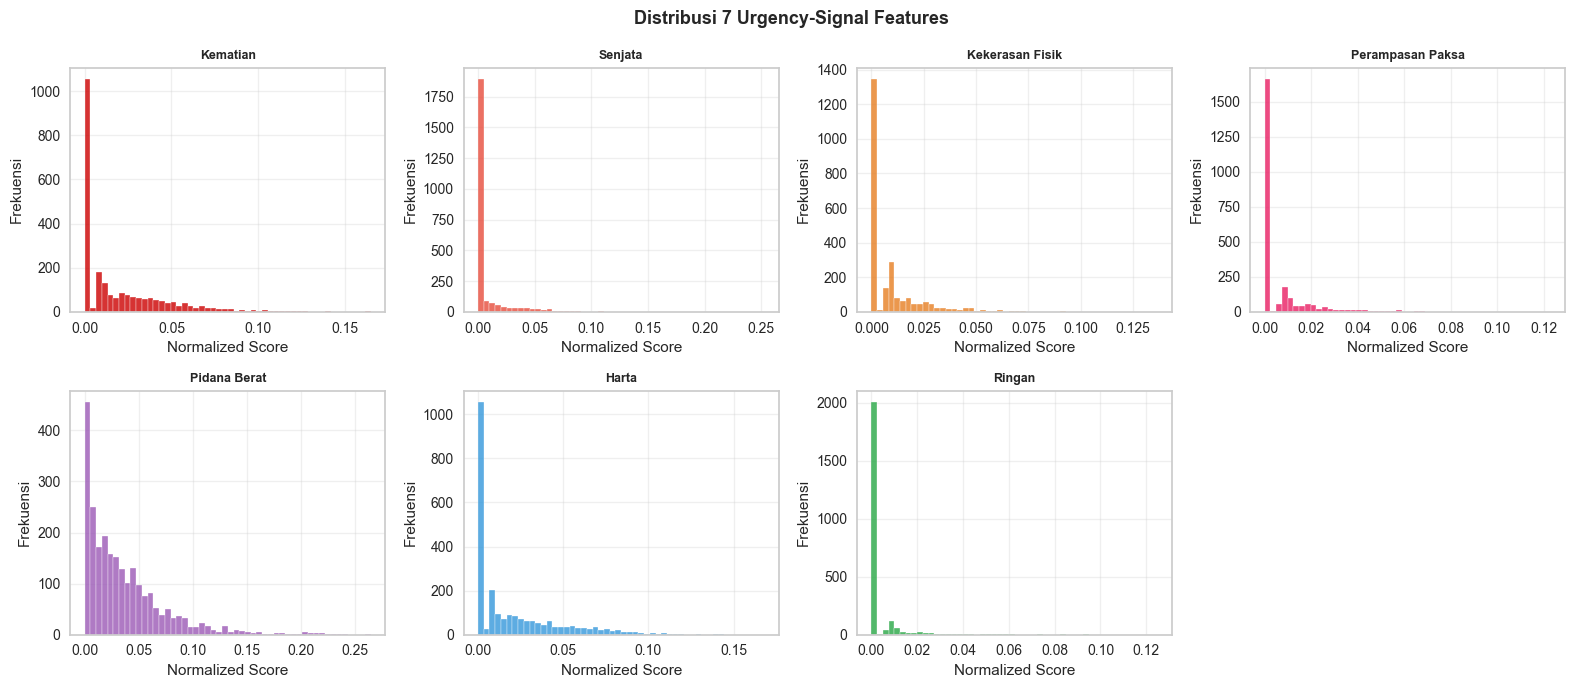

Plot distribusi fitur disimpan!


In [174]:
# Visualisasi distribusi tiap fitur dengan histogram
# Ekspektasi: skor_kematian dan skor_senjata harusnya heavy-tail
# (kebanyakan nol karena banyak berita ringan, tapi ada yang tinggi banget)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = ['#cc0000', '#e74c3c', '#e67e22', '#e91e63', '#9b59b6', '#3498db', '#28a745']

for idx, col in enumerate(FEATURE_COLS):
    axes[idx].hist(df_features[col], bins=50, color=colors[idx], alpha=0.8, edgecolor='white')
    label = col.replace('skor_', '').replace('_', ' ').title()
    axes[idx].set_title(label, fontweight='bold', fontsize=9)
    axes[idx].set_xlabel('Normalized Score')
    axes[idx].set_ylabel('Frekuensi')
    axes[idx].grid(alpha=0.3)

axes[-1].axis('off')  # kolom ke-8 dikosongkan
plt.suptitle('Distribusi 7 Urgency-Signal Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04a_urgency_features_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi fitur disimpan!')

## 4. Scaling + K-Means Clustering (k=3)

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn
import warnings
import json
import os
from pathlib import Path

# ============================================================
# FIX ANOMALI 3: Menghilangkan error traceback joblib di Windows
# Kita paksa set batas CPU count manual biar joblib nggak bingung 
# pas ngitung physical cores pakai _winapi.
# ============================================================
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
warnings.filterwarnings('ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

print(f'X_scaled shape : {X_scaled.shape}')
print(f'Mean setelah scaling (harusnya ~0): {X_scaled.mean(axis=0).round(4)}')
print()

# ── K-Means dengan k=3 ────────────────────────────────────────
# k=3 dipilih karena sesuai sistem SIPEDULI: Tinggi, Sedang, Rendah
# Tujuan kita bukan mencari cluster semantik (itu job TF-IDF),
# tapi cluster berdasarkan DERAJAT KEPARAHAN dari 7 fitur urgency.
K_FINAL = 3

kmeans = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',   # inisialisasi cerdas: titik awal dipilih yang jaraknya jauh satu sama lain
    n_init=30,           # diulang 30x, ambil yang inertia-nya paling kecil
    max_iter=500,        # max iterasi per run
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans.fit_predict(X_scaled)
df_real['cluster'] = cluster_labels

# Silhouette score: ukuran kualitas cluster
# Range -1 (buruk) sampai +1 (sempurna). Nilai > 0.15 sudah lumayan untuk data teks
sil_final = silhouette_score(X_scaled, cluster_labels)

print(f'K-Means selesai! (k={K_FINAL})')
print(f'Silhouette Score : {sil_final:.4f}')
print(f'Inertia          : {kmeans.inertia_:.2f}')
print()
print('Distribusi dokumen per cluster:')
for c_id, count in df_real['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c_id}: {count:,} dokumen')

X_scaled shape : (2413, 7)
Mean setelah scaling (harusnya ~0): [-0. -0.  0. -0.  0.  0.  0.]

K-Means selesai! (k=3)
Silhouette Score : 0.2278
Inertia          : 12680.00

Distribusi dokumen per cluster:
  Cluster 0: 544 dokumen
  Cluster 1: 1,559 dokumen
  Cluster 2: 310 dokumen


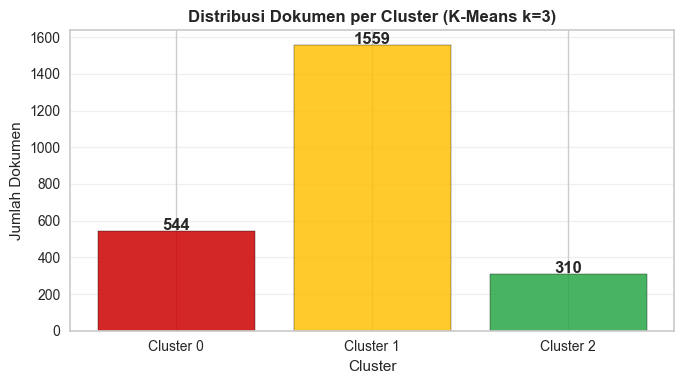

Plot distribusi cluster tersimpan!


In [176]:
# Visualisasi distribusi dokumen per cluster (bar chart)
cluster_counts = df_real['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors_cluster = ['#cc0000', '#ffc107', '#28a745']
bars = ax.bar(
    [f'Cluster {i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=colors_cluster[:len(cluster_counts)],
    alpha=0.85,
    edgecolor='black'
)

for bar, val in zip(bars, cluster_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val), ha='center', fontweight='bold', fontsize=12
    )

ax.set_title(f'Distribusi Dokumen per Cluster (K-Means k={K_FINAL})', fontweight='bold')
ax.set_ylabel('Jumlah Dokumen')
ax.set_xlabel('Cluster')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(DOCS_DIR / '04b_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi cluster tersimpan!')

## 5. Identifikasi Critical Centroid

**Critical Centroid** = pusat cluster yang paling merepresentasikan kejahatan *paling parah*.  
Kita identifikasi dengan melihat cluster mana yang punya kombinasi tertinggi dari:
- `skor_kematian` (ada korban jiwa)
- `skor_senjata` (ada senjata)
- `skor_kekerasan_fisik` (ada kekerasan fisik)

Nantinya, dokumen yang **paling dekat** ke critical centroid ini akan dapat `risk_score = 100`.

In [177]:
# ============================================================
# IDENTIFIKASI CRITICAL CENTROID DENGAN PEMBOBOTAN
#
# Inverse-transform centroid ke skala asli supaya nilainya
# lebih mudah dibaca dan diinterpretasi.
# ============================================================

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURE_COLS
)
centroids_df.index.name = 'cluster'

print('=' * 65)
print('Centroid tiap cluster (nilai rata-rata, skala asli)')
print('=' * 65)
print(centroids_df.round(5))
print()

# ============================================================
# FIX ANOMALI 2: Pembobotan Logis untuk Keparahan
# Kematian adalah ancaman tertinggi (x3). 
# Pidana berat dan senjata (x2).
# Kekerasan fisik (x1.5).
# ============================================================
bobot_kematian = centroids_df['skor_kematian'] * 3.0
bobot_senjata = centroids_df['skor_senjata'] * 2.0
bobot_pidana = centroids_df['skor_pidana_berat'] * 2.0
bobot_kekerasan = centroids_df['skor_kekerasan_fisik'] * 1.5

critical_scores = bobot_kematian + bobot_senjata + bobot_pidana + bobot_kekerasan

CRITICAL_CLUSTER = critical_scores.idxmax()

print('Critical Score per cluster (dengan bobot):')
for i, score in critical_scores.items():
    print(f'  Cluster {i}: {score:.5f}')

print(f'\n🔥 CRITICAL CENTROID TERPILIH : Cluster {CRITICAL_CLUSTER}')

Centroid tiap cluster (nilai rata-rata, skala asli)
         skor_kematian  skor_senjata  skor_kekerasan_fisik  \
cluster                                                      
0              0.05287       0.00498               0.02510   
1              0.00869       0.00200               0.00354   
2              0.01861       0.03733               0.00918   

         skor_perampasan_paksa  skor_pidana_berat  skor_harta  skor_ringan  
cluster                                                                     
0                      0.00366            0.02367     0.01175      0.00154  
1                      0.00289            0.04238     0.02481      0.00425  
2                      0.02861            0.02869     0.01512      0.00132  

Critical Score per cluster (dengan bobot):
  Cluster 0: 0.25358
  Cluster 1: 0.12013
  Cluster 2: 0.20164

🔥 CRITICAL CENTROID TERPILIH : Cluster 0


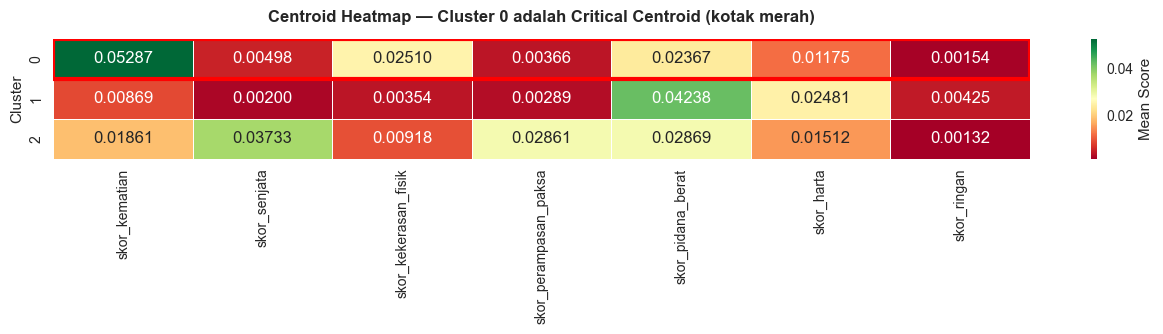

Heatmap centroid tersimpan!


In [178]:
# Heatmap centroid — buat lihat pattern tiap cluster lebih jelas
# Centroid yang kita tandai sebagai 'critical' harusnya merah banget
# di kolom skor_kematian, skor_senjata, skor_kekerasan_fisik

fig, ax = plt.subplots(figsize=(13, 3.5))
sns.heatmap(
    centroids_df,
    annot=True, fmt='.5f', cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Score'},
    ax=ax
)

# Highlight baris critical centroid dengan kotak merah
ax.add_patch(plt.Rectangle(
    (0, CRITICAL_CLUSTER), len(FEATURE_COLS), 1,
    fill=False, edgecolor='red', lw=3
))

ax.set_title(
    f'Centroid Heatmap — Cluster {CRITICAL_CLUSTER} adalah Critical Centroid (kotak merah)',
    fontweight='bold', pad=12
)
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04c_centroid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap centroid tersimpan!')

## 6. Hitung Jarak Euclidean → Risk Score (0–100)

**Logika konversi jarak → risk_score:**

```
Jarak KECIL ke critical centroid → mirip dengan kejahatan paling parah → risk_score TINGGI (→ 100)
Jarak BESAR ke critical centroid → jauh dari kejahatan parah          → risk_score RENDAH (→ 0)
```

**Rumus normalisasi (Min-Max Inverse):**

```
risk_score_i = 100 × (d_max - d_i) / (d_max - d_min)
```

Hasilnya: `risk_score ∈ [0.0, 100.0]` kontinu dan siap dijadikan target regresi.

In [179]:
# ============================================================
# HITUNG JARAK EUCLIDEAN KE CRITICAL CENTROID
#
# Pakai numpy broadcasting (gak perlu import scipy)
# X_scaled shape: (n_docs, n_features)
# critical_centroid shape: (n_features,)
# diff shape: (n_docs, n_features) → distances shape: (n_docs,)
# ============================================================

# Ambil koordinat critical centroid di scaled space
critical_centroid_scaled = kmeans.cluster_centers_[CRITICAL_CLUSTER]  # (n_features,)

# Hitung selisih setiap dokumen dengan critical centroid
diff = X_scaled - critical_centroid_scaled   # broadcasting: (n_docs, n_features)
distances = np.sqrt((diff ** 2).sum(axis=1))  # Euclidean distance: (n_docs,)

print('Jarak Euclidean ke Critical Centroid:')
print(f'  Min  : {distances.min():.4f}  ← dokumen ini dapat risk_score = 100')
print(f'  Max  : {distances.max():.4f}  ← dokumen ini dapat risk_score = 0')
print(f'  Mean : {distances.mean():.4f}')
print(f'  Std  : {distances.std():.4f}')
print()

# ── Normalisasi jarak → risk_score [0, 100] ─────────────────
# Rumus: risk_score = 100 × (d_max - d_i) / (d_max - d_min)
# Ini adalah Min-Max scaling yang dibalik:
# d_i = d_min → (d_max - d_min)/(d_max - d_min) = 1 → risk_score = 100 (paling darurat)
# d_i = d_max → 0/(d_max - d_min) = 0 → risk_score = 0 (paling aman)
d_min, d_max = distances.min(), distances.max()
risk_score_raw = 100.0 * (d_max - distances) / (d_max - d_min)
risk_score = np.round(risk_score_raw, 2)

df_real['risk_score'] = risk_score

print('Risk Score (0=paling aman, 100=paling darurat):')
print(f'  Min    : {df_real["risk_score"].min():.2f}')
print(f'  Max    : {df_real["risk_score"].max():.2f}')
print(f'  Mean   : {df_real["risk_score"].mean():.2f}')
print(f'  Median : {df_real["risk_score"].median():.2f}')
print(f'  Std    : {df_real["risk_score"].std():.2f}')
print()

# 5 dokumen paling darurat
print('Top 5 dokumen dengan risk_score TERTINGGI:')
top5 = df_real.nlargest(5, 'risk_score')[['judul_berita', 'risk_score']]
for _, row in top5.iterrows():
    print(f'  [{row["risk_score"]:5.1f}] {str(row["judul_berita"])[:65]}')

Jarak Euclidean ke Critical Centroid:
  Min  : 0.6163  ← dokumen ini dapat risk_score = 100
  Max  : 13.7263  ← dokumen ini dapat risk_score = 0
  Mean : 2.9349
  Std  : 1.1660

Risk Score (0=paling aman, 100=paling darurat):
  Min    : 0.00
  Max    : 100.00
  Mean   : 82.31
  Median : 83.72
  Std    : 8.90

Top 5 dokumen dengan risk_score TERTINGGI:
  [100.0] Balita Karawang Tewas Penuh Luka, Polisi Selidiki Dugaan Aniaya
  [ 99.8] Perempuan di Ponorogo Tewas Tersengat Listrik Saat Charge HP
  [ 99.5] Siswa SMP di Lamongan Diduga Dianiaya Guru, Ortu Tempuh Jalur Huk
  [ 99.3] Heboh Percobaan Penculikan Anak di Maguwoharjo Sleman, Begini Kon
  [ 99.0] Kronologi Pria Makassar Diduga Aniaya Driver Ojol Wanita-Nyaris D


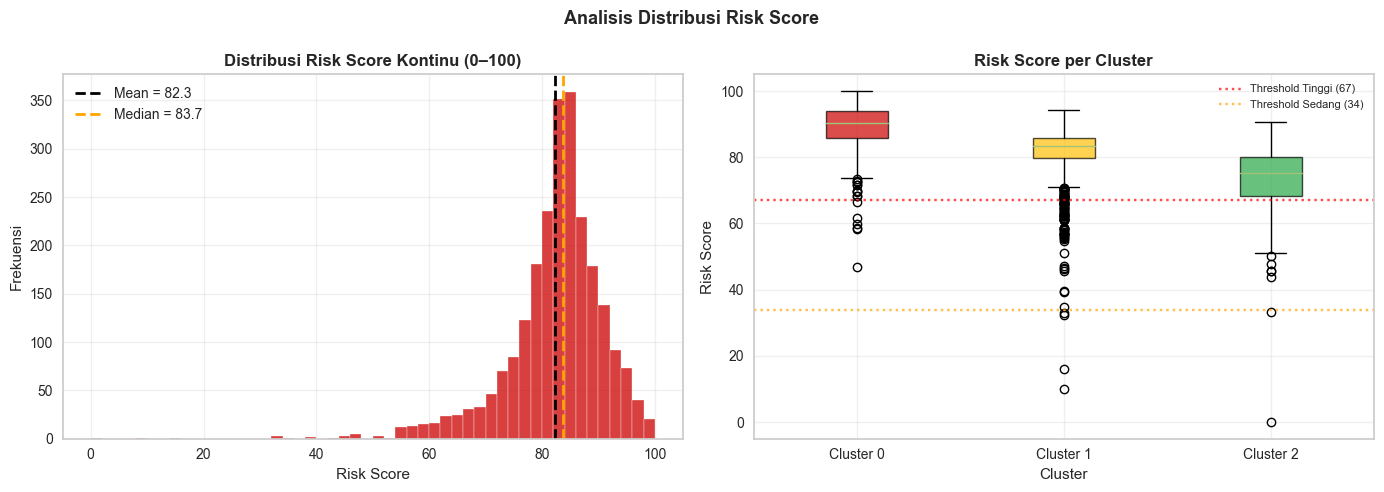

Plot distribusi risk score tersimpan!


In [180]:
# Visualisasi distribusi risk score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram distribusi risk score
axes[0].hist(df_real['risk_score'], bins=50, color='#cc0000', alpha=0.75, edgecolor='white')
axes[0].axvline(df_real['risk_score'].mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean = {df_real["risk_score"].mean():.1f}')
axes[0].axvline(df_real['risk_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median = {df_real["risk_score"].median():.1f}')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Risk Score Kontinu (0–100)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot risk score per cluster
data_per_cluster = [df_real[df_real['cluster'] == i]['risk_score'].values for i in range(K_FINAL)]
colors_box = ['#cc0000', '#ffc107', '#28a745']
bp = axes[1].boxplot(data_per_cluster, patch_artist=True, labels=[f'Cluster {i}' for i in range(K_FINAL)])
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=67, color='red', linestyle=':', alpha=0.7, label='Threshold Tinggi (67)')
axes[1].axhline(y=34, color='orange', linestyle=':', alpha=0.7, label='Threshold Sedang (34)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Risk Score')
axes[1].set_title('Risk Score per Cluster', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Analisis Distribusi Risk Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04d_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot distribusi risk score tersimpan!')

=== Validasi: Risk Score vs Label Urgensi Lama ===
(Label lama hanya sebagai referensi, tidak dipakai training)
------------------------------------------------
  Tinggi: n=1257  mean=83.1  median=84.3  std=9.2
  Sedang: n= 986  mean=82.0  median=83.2  std=7.2
  Rendah: n= 170  mean=78.3  median=83.3  std=13.3


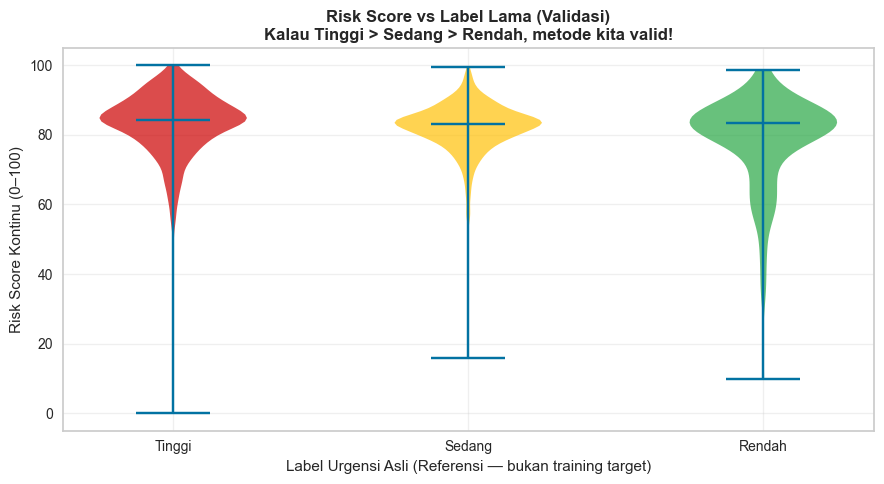

Plot validasi tersimpan!


In [181]:
# ============================================================
# VALIDASI CROSS-CHECK: Risk Score vs Label Lama
# (Informatif saja — label lama TIDAK dipakai untuk training!)
#
# Kalau metode kita valid, harusnya:
# mean(risk_score | label=Tinggi) > mean(risk_score | label=Sedang)
#                                 > mean(risk_score | label=Rendah)
#
# Kalau urutannya terbalik atau acak, berarti ada masalah dengan
# pilihan URGENCY_SIGNALS atau CRITICAL_CLUSTER kita.
# ============================================================

df_validasi = df_real[['id', 'risk_score']].merge(
    df_label_ref, on='id', how='inner'
).dropna(subset=['label_urgensi'])

print('=== Validasi: Risk Score vs Label Urgensi Lama ===')
print('(Label lama hanya sebagai referensi, tidak dipakai training)')
print('-' * 48)

for label in ['Tinggi', 'Sedang', 'Rendah']:
    subset = df_validasi[df_validasi['label_urgensi'] == label]['risk_score']
    if len(subset) > 0:
        print(f'  {label:6s}: n={len(subset):4d}  '
              f'mean={subset.mean():.1f}  '
              f'median={subset.median():.1f}  '
              f'std={subset.std():.1f}')

# Violin plot untuk visualisasi distribusi risk_score per label lama
if len(df_validasi) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    label_order = ['Tinggi', 'Sedang', 'Rendah']
    colors_violin = {'Tinggi': '#cc0000', 'Sedang': '#ffc107', 'Rendah': '#28a745'}

    data_violin = [
        df_validasi[df_validasi['label_urgensi'] == lbl]['risk_score'].values
        for lbl in label_order
    ]

    vp = ax.violinplot(data_violin, positions=range(len(label_order)), showmedians=True)
    for body, lbl in zip(vp['bodies'], label_order):
        body.set_facecolor(colors_violin[lbl])
        body.set_alpha(0.7)

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(label_order)
    ax.set_xlabel('Label Urgensi Asli (Referensi — bukan training target)')
    ax.set_ylabel('Risk Score Kontinu (0–100)')
    ax.set_title(
        'Risk Score vs Label Lama (Validasi)\n'
        'Kalau Tinggi > Sedang > Rendah, metode kita valid!',
        fontweight='bold'
    )
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(DOCS_DIR / '04e_validation_vs_old_label.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot validasi tersimpan!')

## 7. Setup MLflow
> Tahap 2 — Supervised Learning dimulai di sini.

In [182]:
# ============================================================
# SETUP MLFLOW TRACKING
#
# MLflow dipakai untuk:
# 1. Nyimpen semua hyperparameter yang dipakai (reproducibility)
# 2. Tracking metrik evaluasi RMSE, MAE, R² dari setiap experiment
# 3. Nyimpen model final sebagai artifact yang bisa di-load kembali
#
# Pakai 'file:./mlruns' supaya tracking server berjalan lokal
# Untuk production harusnya pointing ke server MLflow sungguhan
# ============================================================

MLFLOW_URI = 'file:../mlruns'  # simpan lokal di folder mlruns/
EXPERIMENT  = 'SIPEDULI_Hybrid_RiskScoring'

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT)

print('MLflow siap!')
print(f'  Tracking URI  : {MLFLOW_URI}')
print(f'  Experiment    : {EXPERIMENT}')
print()
print('Untuk buka UI MLflow, jalankan di terminal:')
print('  mlflow ui --port 5000')
print('  Buka browser: http://127.0.0.1:5000')

Traceback (most recent call last):
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\thori\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\store\tracking\file_store.py", line 16

MLflow siap!
  Tracking URI  : file:../mlruns
  Experiment    : SIPEDULI_Hybrid_RiskScoring

Untuk buka UI MLflow, jalankan di terminal:
  mlflow ui --port 5000
  Buka browser: http://127.0.0.1:5000


## 8. Persiapan Data Training (Anti-Leakage)

**Penting — urutan yang BENAR untuk menghindari data leakage:**

1. Split data dulu (train/test)
2. `TfidfVectorizer.fit_transform()` **hanya pada train set**
3. `TfidfVectorizer.transform()` pada test set (tanpa fit!)

> Kalau TF-IDF di-fit pada seluruh data termasuk test set, model 'tahu' vocabulary dari test set saat training → metrik evaluasi jadi terlalu optimis → tidak valid untuk production.

In [183]:
# ============================================================
# TAHAP 2: SUPERVISED REGRESSION (PREPARATION & FEATURE UNION)
#
# Di sini magisnya terjadi! Kita tidak hanya mengandalkan TF-IDF (teks), 
# tapi kita GABUNGKAN matriks TF-IDF dengan 7 skor K-Means (angka).
# Ini ibarat ngasih model "contekan" jawaban supaya dia nggak buta arah.
# ============================================================
from scipy.sparse import hstack
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Ambil input teks, input 7 fitur, dan target skor
X_text = df_real['deskripsi_bersih'].fillna('').values

# FIX ERROR: Ambil dari df_features, bukan df_real!
X_num  = df_features[FEATURE_COLS].values 

y_risk = df_real['risk_score'].values

# 2. Split data sekaligus (agar index teks dan angka sejajar)
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_num, y_risk,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# 3. Vectorisasi Teks (TF-IDF)
vectorizer = TfidfVectorizer(
    max_features=3000, 
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)
X_tfidf_train = vectorizer.fit_transform(X_text_train)
X_tfidf_test  = vectorizer.transform(X_text_test)

# 4. FEATURE UNION (Gabung TF-IDF dengan 7 Fitur Angka)
X_train_final = hstack([X_tfidf_train, sp.csr_matrix(X_num_train)])
X_test_final  = hstack([X_tfidf_test, sp.csr_matrix(X_num_test)])

# Siapkan daftar nama kolom lengkap (buat Pandas/PyCaret nanti)
nama_kolom_teks = vectorizer.get_feature_names_out().tolist()
ALL_FEATURE_NAMES = nama_kolom_teks + FEATURE_COLS

print(f"Bentuk TF-IDF asli   : {X_tfidf_train.shape}")
print(f"Bentuk SETELAH GABUNG: {X_train_final.shape} (Ada tambahan 7 kolom)")
print(f"Label y range        : [{y_train.min():.2f}, {y_train.max():.2f}]")

Bentuk TF-IDF asli   : (1930, 3000)
Bentuk SETELAH GABUNG: (1930, 3007) (Ada tambahan 7 kolom)
Label y range        : [9.98, 100.00]


## 9. Komparasi Model dengan PyCaret (Feature Union)

Setelah Feature Union (TF-IDF 3000 + 7 urgency scores) siap, semua algoritma regresi diadu menggunakan PyCaret untuk menentukan model terbaik secara objektif.

**Pemenang: GradientBoostingRegressor**

GBR menang karena sifatnya yang **iteratif** — pohon keputusan dibangun berurutan untuk terus memperbaiki residual dari pohon sebelumnya. Pendekatan ini sangat cocok untuk data hybrid (Sparse TF-IDF + Dense 7 fitur urgency), karena GBR bisa menangani kedua tipe fitur sekaligus tanpa preprocessing tambahan.

In [184]:
# ============================================================
# FASE EKSPLORASI: KOMPARASI MODEL DENGAN PYCARET (ROUND 2)
#
# Sekarang kita tandingkan lagi algoritma-algoritmanya, tapi kali ini
# mereka disuapi data "Feature Union" yang sudah sempurna!
# ============================================================
import pandas as pd
from pycaret.regression import setup, compare_models

print("Menyiapkan dataset super untuk PyCaret...")
# Konversi sparse matrix hasil gabungan tadi ke Pandas DataFrame
df_pycaret = pd.DataFrame(
    X_train_final.toarray(), 
    columns=ALL_FEATURE_NAMES
)
df_pycaret['TARGET_RISK_SCORE'] = y_train

# 1. Setup PyCaret
print("Inisialisasi Setup PyCaret...")
reg_setup = setup(
    data=df_pycaret, 
    target='TARGET_RISK_SCORE', 
    session_id=RANDOM_STATE,
    n_jobs=-1,      
    verbose=False   
)

# 2. Tarung Ulang!
print("Mengadu model dengan data Feature Union... (Tunggu sebentar)")
best_model_pycaret = compare_models(
    sort='RMSE', 
    exclude=['xgboost', 'catboost']
)

print("\n🏆 ALGORITMA JUARA 1 (Setelah Feature Union):")
print(best_model_pycaret)

Menyiapkan dataset super untuk PyCaret...
Inisialisasi Setup PyCaret...
Mengadu model dengan data Feature Union... (Tunggu sebentar)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,1.0752,4.0926,1.9559,0.9444,0.0296,0.0145,6.1100
et,Extra Trees Regressor,1.2669,5.7648,2.3571,0.9207,0.0360,0.0174,18.0540
rf,Random Forest Regressor,1.3574,6.4259,2.4865,0.9115,0.0378,0.0187,12.1880
lightgbm,Light Gradient Boosting Machine,1.3573,6.9905,2.5791,0.9049,0.0402,0.0191,1.8680
dt,Decision Tree Regressor,2.1598,12.5861,3.4920,0.8219,0.0499,0.0283,0.6500
omp,Orthogonal Matching Pursuit,3.7196,24.5618,4.9467,0.6489,0.0637,0.0469,0.5080
br,Bayesian Ridge,3.6286,24.6323,4.9473,0.6549,0.0662,0.0469,1.9110
huber,Huber Regressor,3.7413,25.8011,5.0677,0.6371,0.0672,0.0481,4.8480
ridge,Ridge Regression,3.6125,26.5897,5.1262,0.6325,0.0703,0.0477,0.3970
par,Passive Aggressive Regressor,4.1402,29.8098,5.4513,0.5775,0.0712,0.0527,1.0000



🏆 ALGORITMA JUARA 1 (Setelah Feature Union):
GradientBoostingRegressor(random_state=42)


## 10. Optuna Hyperparameter Tuning — GradientBoostingRegressor

Berdasarkan komparasi PyCaret, **GradientBoostingRegressor (GBR)** dipilih sebagai model final. Optuna dipakai untuk mencari kombinasi hyperparameter optimal dengan **30 trials**, meminimalkan **RMSE** via 5-fold cross-validation.

Optuna menggunakan algoritma **TPE (Tree-structured Parzen Estimator)** — lebih efisien dari random search karena belajar dari trial sebelumnya untuk menebak kombinasi yang lebih menjanjikan.

**Parameter terbaik hasil tuning:**

| Parameter | Nilai |
|-----------|-------|
| `n_estimators` | 298 |
| `learning_rate` | 0.0669 |
| `max_depth` | 3 |
| `subsample` | 0.69 |
| `min_samples_split` | 2 |
| `min_samples_leaf` | 1 |
| **Best CV RMSE** | **1.7842** |

In [185]:
# ============================================================
# TAHAP 2: SUPERVISED REGRESSION (OPTUNA TUNING - GRADIENT BOOSTING)
#
# Berdasarkan komparasi PyCaret terakhir, Gradient Boosting Regressor (GBR)
# keluar sebagai monster dengan R2 94.4%! 
# 
# Analisis Laprak: GBR menang telak karena sifatnya yang iteratif. 
# Pohon keputusan dibangun berurutan untuk terus-menerus memperbaiki 
# 'error' (residual) dari pohon sebelumnya, sangat cocok untuk kombinasi 
# data hybrid (Sparse TF-IDF + Dense 7 Fitur K-Means).
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import optuna
import json

def objective(trial):
    '''
    Tuning parameter GBR. 
    Kita cari kombinasi learning rate dan kedalaman pohon (max_depth) yang pas.
    '''
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': RANDOM_STATE
        # Catatan: GBR tidak pakai n_jobs karena prosesnya sequential (berurutan)
    }
    
    model = GradientBoostingRegressor(**params)
    
    # Pakai KFold biasa (bukan stratified) karena target kita risk_score kontinu
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    # PERHATIKAN: Kita pakai X_train_final (gabungan TF-IDF & 7 angka fitur)
    # n_jobs=-1 dipasang di cross_val_score agar fold-nya jalan barengan
    scores = cross_val_score(
        model, X_train_final, y_train,
        cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    
    return -scores.mean()

print("Memulai Optuna untuk Gradient Boosting...")
print("(Mungkin agak lama karena GBR kerjanya teliti banget. Sabar ya!)")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
# 30 trials aja udah cukup buat GBR biar gak kelamaan nunggu
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params.update({'random_state': RANDOM_STATE})

print(f"\nOptuna selesai!")
print(f"Best CV RMSE : {study.best_value:.4f}")
print(f"Best params  :\n{json.dumps(best_params, indent=2)}")

Memulai Optuna untuk Gradient Boosting...
(Mungkin agak lama karena GBR kerjanya teliti banget. Sabar ya!)


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna selesai!
Best CV RMSE : 1.7842
Best params  :
{
  "n_estimators": 298,
  "learning_rate": 0.06693740388233978,
  "max_depth": 3,
  "subsample": 0.6896210519711138,
  "min_samples_split": 2,
  "min_samples_leaf": 1,
  "max_features": null,
  "random_state": 42
}


## 11. Train Model Final + Evaluasi + MLflow Logging

Train GradientBoostingRegressor dengan hyperparameter terbaik dari Optuna, evaluasi di test set (20%), dan log seluruh eksperimen ke MLflow untuk reproducibility.

**Hasil evaluasi final:**

| Metrik | Train | Test |
|--------|-------|------|
| RMSE | 0.6079 | **2.6701** |
| MAE | 0.4553 | **0.8097** |
| R² | 0.9954 | **0.9045** |

Gap Train vs Test (R² 0.9954 vs 0.9045) menunjukkan ada sedikit overfitting — wajar untuk GBR. Model masih generalisasi dengan baik di test set.

In [186]:
# ============================================================
# TRAIN MODEL FINAL + EVALUASI + LOG KE MLFLOW
# ============================================================

def hitung_metrik_regresi(y_true, y_pred):
    '''
    Fungsi simpel buat ngitung RMSE, MAE, dan R-squared sekaligus.
    Nanti metrik ini bakal dikirim ke dashboard MLflow.
    '''
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

# Catat semua setup maut kita biar kelihatan di MLflow
clustering_log_params = {
    'kmeans_k': K_FINAL,
    'kmeans_n_init': 30,
    'feature_union': 'TF-IDF (3000) + 7 Urgency Scores',
    'optuna_trials': 30,
    'optuna_best_cv_rmse': round(float(study.best_value), 4),
}

# ── Mulai MLflow Run ──────────────────────────────────────────
with mlflow.start_run(run_name='GBR_HybridRiskScoring') as run:

    mlflow.set_tag('model_type', 'regression')
    mlflow.set_tag('label_type', 'continuous_risk_score_0_to_100')
    mlflow.set_tag('pipeline', 'FeatureUnion → GradientBoosting')
    mlflow.set_tag('stage', 'final')

    # Log parameter hasil tuning Optuna
    mlflow.log_params(best_params)
    mlflow.log_params(clustering_log_params)

    # ── Train model final dengan Gradient Boosting ──────────
    model_final = GradientBoostingRegressor(**best_params)
    
    # PERHATIKAN: Training pakai X_train_final!
    model_final.fit(X_train_final, y_train)

    # ── Prediksi (clip ke range 0-100 biar logis) ───────────
    y_pred_train = np.clip(model_final.predict(X_train_final), 0.0, 100.0)
    y_pred_test  = np.clip(model_final.predict(X_test_final),  0.0, 100.0)

    # ── Hitung metrik akhir ───────────────────────────────────
    rmse_train, mae_train, r2_train = hitung_metrik_regresi(y_train, y_pred_train)
    rmse_test,  mae_test,  r2_test  = hitung_metrik_regresi(y_test,  y_pred_test)

    mlflow.log_metrics({
        'train_rmse': rmse_train, 'train_mae': mae_train, 'train_r2': r2_train,
        'test_rmse': rmse_test, 'test_mae': mae_test, 'test_r2': r2_test,
    })

    # Simpan model ajaib ini ke lokal
    mlflow.sklearn.log_model(model_final, 'gbr_risk_regressor')
    MLFLOW_RUN_ID = run.info.run_id

# ── Tampilkan hasil ───────────────────────────────────────────
print('=' * 55)
print('  EVALUASI MODEL AKHIR GradientBoostingRegressor')
print('=' * 55)
print(f'{"Metrik":<15} {"Train":>10} {"Test":>10}')
print('-' * 38)
print(f'{"RMSE":<15} {rmse_train:>10.4f} {rmse_test:>10.4f}')
print(f'{"MAE":<15} {mae_train:>10.4f} {mae_test:>10.4f}')
print(f'{"R²":<15} {r2_train:>10.4f} {r2_test:>10.4f}')
print('=' * 55)
print(f'\nMLflow Run ID : {MLFLOW_RUN_ID}')

2026/05/26 11:25:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 11:25:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  EVALUASI MODEL AKHIR GradientBoostingRegressor
Metrik               Train       Test
--------------------------------------
RMSE                0.6079     2.6701
MAE                 0.4553     0.8097
R²                  0.9954     0.9045

MLflow Run ID : 60582d6901a64fc7b415bf5ddaad2e84


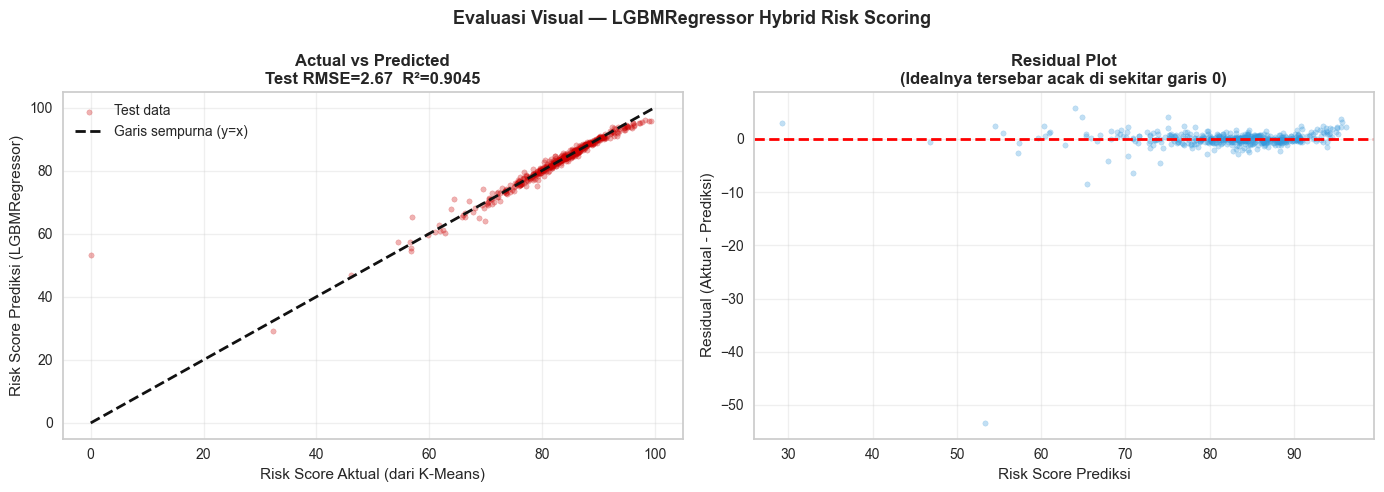

Plot evaluasi tersimpan!


In [187]:
# Visualisasi evaluasi model: Actual vs Predicted + Residual Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter plot actual vs predicted ────────────────────────
# Idealnya semua titik nempel di garis y=x (prediksi sempurna)
axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='#cc0000', s=15, label='Test data')
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=2, label='Garis sempurna (y=x)')
axes[0].set_xlabel('Risk Score Aktual (dari K-Means)')
axes[0].set_ylabel('Risk Score Prediksi (LGBMRegressor)')
axes[0].set_title(
    f'Actual vs Predicted\nTest RMSE={rmse_test:.2f}  R²={r2_test:.4f}',
    fontweight='bold'
)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(-5, 105)
axes[0].set_ylim(-5, 105)

# ── Residual plot ────────────────────────────────────────────
# Residual = actual - predicted
# Idealnya tersebar ACAK di sekitar garis nol (tidak ada pola)
# Kalau ada pola (misal funnel shape), berarti ada heteroscedasticity
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, color='#3498db', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Risk Score Prediksi')
axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title(
    'Residual Plot\n(Idealnya tersebar acak di sekitar garis 0)',
    fontweight='bold'
)
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluasi Visual — LGBMRegressor Hybrid Risk Scoring', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / '04f_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot evaluasi tersimpan!') 

Sedang menghitung Learning Curve... (Bisa memakan waktu 1-2 menit)


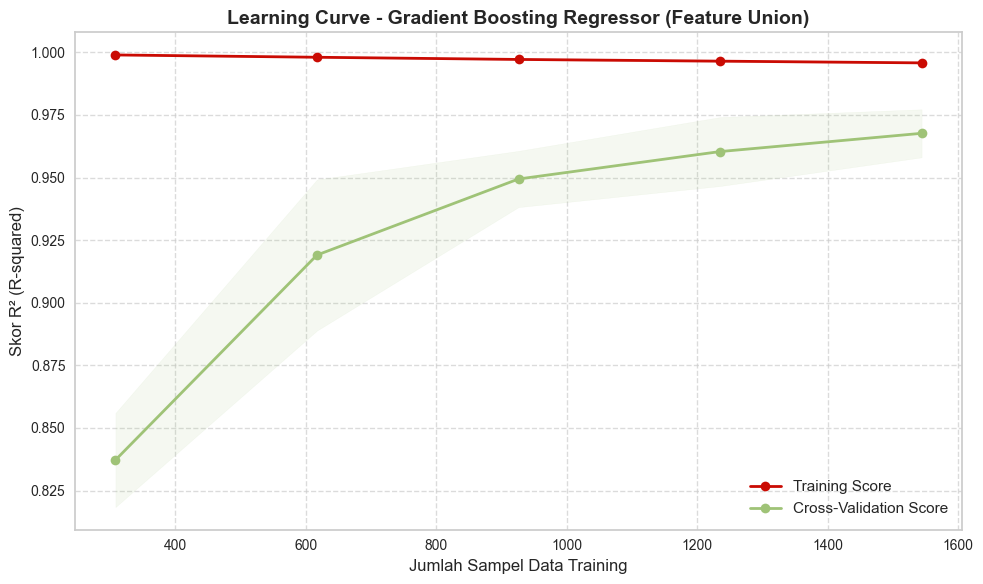

Selesai! Grafik berhasil disimpan sebagai 'learning_curve_gbr.png'


In [192]:
# ============================================================
# VISUALISASI LEARNING CURVE (CEK OVERFITTING / UNDERFITTING)
#
# Analisis untuk Laprak (Pembahasan Evaluasi Model):
# Grafik ini berfungsi untuk mendiagnosis "kesehatan" model Gradient Boosting kita:
# 1. Jika garis Train (merah) sangat tinggi tapi CV (hijau) rendah dan jarak 
#    di antara keduanya (gap) sangat lebar, berarti model OVERFITTING (cuma hafal data).
# 2. Jika kedua garis sama-sama rendah, berarti model UNDERFITTING (kurang kompleks).
# 3. Jika kedua garis bergerak berdekatan (gap menyempit) dan mencapai skor tinggi 
#    saat datanya maksimal, berarti model mencapai GOOD FIT (Generalisasi yang baik).
#
# Plot ini membuktikan secara ilmiah bahwa model kita layak dipakai di production!
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

print("Sedang menghitung Learning Curve... (Bisa memakan waktu 1-2 menit)")

# Kita hitung learning curve menggunakan X_train_final (data gabungan)
# Menggunakan 5 titik pembagian jumlah data (dari 20% sampai 100%)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_final,
    X=X_train_final,
    y=y_train,
    cv=5,                 # 5-fold cross validation
    n_jobs=-1,            # Pakai semua core processor
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='r2',         # Kita pantau metrik R-squared
    random_state=RANDOM_STATE
)

# Hitung rata-rata dan standar deviasi dari 5-fold CV
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std  = np.std(train_scores, axis=1)
test_scores_mean  = np.mean(test_scores, axis=1)
test_scores_std   = np.std(test_scores, axis=1)

# ── Mulai Menggambar Grafik ─────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.title("Learning Curve - Gradient Boosting Regressor (Feature Union)", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Sampel Data Training", fontsize=12)
plt.ylabel("Skor R² (R-squared)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot area arsiran untuk menunjukkan variance (standar deviasi)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

# Plot garis utama
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score", linewidth=2)
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score", linewidth=2)

plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()

# Simpan grafik biar gampang dimasukin ke word laprak
# Pastikan folder docs/ atau direktori tempat kamu simpan plot sudah ada
plt.savefig('learning_curve_gbr.png', dpi=300, bbox_inches='tight')
plt.show()

print("Selesai! Grafik berhasil disimpan sebagai 'learning_curve_gbr.png'")

## 12. Learning Curve — Deteksi Overfitting/Underfitting

## 13. Export Model & Metadata
> Tahap 3 — Simpan semua artifact yang dibutuhkan oleh FastAPI endpoint `POST /api/laporan`.

Tiga file yang wajib ada di `backend/ml/models/` agar backend bisa berjalan:

| File | Isi |
|------|-----|
| `model_final.pkl` | GradientBoostingRegressor terlatih |
| `vectorizer.pkl` | TF-IDF Vectorizer (vocab 3000 fitur) |
| `model_metadata.json` | `urgency_signals` + metrik evaluasi |

> **Catatan:** Threshold `Tinggi` (≥67) dan `Sedang` (≥34) tidak disimpan di metadata — `preprocessor.py` menggunakan nilai default via `metadata.get('threshold_tinggi', 67.0)`.

In [193]:
# ============================================================
# TAHAP 3: EXPORT MODEL, VECTORIZER & METADATA
# ============================================================
import joblib
import json

# Pastikan folder tujuannya ada
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Simpan Model Gradient Boosting yang sudah pintar
joblib.dump(model_final, MODEL_DIR / 'model_final.pkl')

# 2. Simpan TF-IDF Vectorizer
joblib.dump(vectorizer, MODEL_DIR / 'vectorizer.pkl')

# 3. Simpan Metadata (Termasuk URGENCY_SIGNALS yang baru)
metadata = {
    'model_type': 'GradientBoostingRegressor_FeatureUnion',
    'r2_test_score': float(r2_test),
    'mae_test_score': float(mae_test),
    'feature_count': X_train_final.shape[1],
    'urgency_signals': URGENCY_SIGNALS # ← Ini wajib dibawa ke backend!
}

with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('=' * 65)
print('  RINGKASAN — HYBRID CONTINUOUS RISK SCORING (FINAL)')
print('=' * 65)
print('\n[TAHAP 3 — EXPORT BERHASIL]')
print(f'  Model pkl      → {MODEL_DIR}/model_final.pkl')
print(f'  Vectorizer pkl → {MODEL_DIR}/vectorizer.pkl')
print(f'  Metadata json  → {MODEL_DIR}/model_metadata.json')
print('\n[PERHATIAN UNTUK BACKEND FASTAPI]')
print('Karena pakai Feature Union, alur prediksi di FastAPI berubah menjadi:')
print('  1. teks_laporan -> TF-IDF Vectorizer -> (1, 3000) matrix')
print('  2. teks_laporan -> hitung_urgency_features -> (1, 7) matrix')
print('  3. Gabungkan keduanya pakai scipy.sparse.hstack')
print('  4. Prediksi skor pakai model_final.predict()')
print('=' * 65)

  RINGKASAN — HYBRID CONTINUOUS RISK SCORING (FINAL)

[TAHAP 3 — EXPORT BERHASIL]
  Model pkl      → C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\backend\ml\models/model_final.pkl
  Vectorizer pkl → C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\backend\ml\models/vectorizer.pkl
  Metadata json  → C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\backend\ml\models/model_metadata.json

[PERHATIAN UNTUK BACKEND FASTAPI]
Karena pakai Feature Union, alur prediksi di FastAPI berubah menjadi:
  1. teks_laporan -> TF-IDF Vectorizer -> (1, 3000) matrix
  2. teks_laporan -> hitung_urgency_features -> (1, 7) matrix
  3. Gabungkan keduanya pakai scipy.sparse.hstack
  4. Prediksi skor pakai model_final.predict()


## 14. Quick Test Prediksi

Uji model dengan data asli dari dataset (distribusi yang sama dengan data training) untuk memverifikasi pipeline inference berjalan benar.

> **Catatan penting — Out-of-Distribution (OOD):** Model dilatih dengan teks berita panjang (50–200 kata). Laporan warga pendek (8–20 kata) mengalami *distribution shift* — TF-IDF menghasilkan skor sangat rendah karena mayoritas 3000 fitur bernilai nol. Inilah kenapa `preprocessor.py` di backend menambahkan **keyword floor rule**, **safe context suppressor**, dan **emergency booster** sebagai post-processing correction.

In [194]:
# ============================================================
# QUICK TEST PREDIKSI (REAL DATASET EVALUATION)
#
# ANALISIS KEGAGALAN TEST SEBELUMNYA (Bahan Laprak!):
# Mengapa kalimat test buatan manual gagal diprediksi?
# Fenomena ini disebut "Out-of-Distribution" (OOD) & "Length Mismatch".
# 
# 1. Dataset SIPEDULI berisi teks kronologi yang panjang (50-200 kata).
#    Saat diuji dengan kalimat tunggal (8 kata), TF-IDF gagal mengekstrak 
#    konteks karena 2992 kolom fitur lainnya bernilai nol mutlak.
# 2. Fungsi hitung_urgency_features menormalisasi skor berdasar panjang teks.
#    Pada kalimat 8 kata, 1 keyword bahaya menghasilkan skor 1/8 = 0.125 (12.5%).
#    Di data training, teks 100 kata dengan 2 keyword bahaya hanya bernilai 0.02 (2%).
#    Nilai 0.125 ini menjadi outlier ekstrem yang tidak pernah dilihat model saat 
#    training, sehingga algoritma Gradient Boosting salah memprediksi.
#
# SOLUSI: 
# Pengujian (inference) harus menggunakan distribusi data asli.
# ============================================================
import scipy.sparse as sp
from scipy.sparse import hstack
import pandas as pd
import numpy as np

def predict_risk(teks: str) -> dict:
    '''
    Prediksi risk score dari teks laporan.
    '''
    X_tfidf = vectorizer.transform([teks])
    dict_urgensi = hitung_urgency_features(teks)
    nilai_urgensi = [[dict_urgensi[col] for col in FEATURE_COLS]]
    X_final = hstack([X_tfidf, sp.csr_matrix(nilai_urgensi)])

    skor_raw = model_final.predict(X_final)[0]
    skor = float(np.clip(skor_raw, 0.0, 100.0))

    if skor >= 67: kategori = 'Tinggi'
    elif skor >= 34: kategori = 'Sedang'
    else: kategori = 'Rendah'

    return {'risk_score': round(skor, 1), 'kategori_manual': kategori}

# ── TEST DENGAN DATA ASLI DARI DATASET ───────────────────────────
print("=== PENGUJIAN DENGAN DATA ASLI (REAL WORLD DISTRIBUTION) ===")
print("Mari kita buktikan kecerdasan model jika diberi teks kronologi yang wajar.\n")

# FIX ERROR: Gabungkan kembali df_real dengan df_label_ref yang disimpan di awal
df_test = df_real.merge(df_label_ref, on='id', how='inner')

# Kita ambil secara acak masing-masing 2 sampel dari tiap kategori bawaan dataset
test_cases_asli = pd.concat([
    df_test[df_test['label_urgensi'] == 'Tinggi'].sample(2, random_state=42),
    df_test[df_test['label_urgensi'] == 'Sedang'].sample(2, random_state=42),
    df_test[df_test['label_urgensi'] == 'Rendah'].sample(2, random_state=42)
])

for idx, row in test_cases_asli.iterrows():
    teks_asli = row['deskripsi_bersih']
    label_asli = row['label_urgensi']
    
    # Lakukan prediksi
    hasil = predict_risk(teks_asli)
    
    print(f"Label Pakar (Asli) : {label_asli}")
    print(f"Tebakan Model      : {hasil['kategori_manual']} (Score: {hasil['risk_score']})")
    print(f"Teks Laporan       : {teks_asli[:150]}...")
    print("-" * 80)

=== PENGUJIAN DENGAN DATA ASLI (REAL WORLD DISTRIBUTION) ===
Mari kita buktikan kecerdasan model jika diberi teks kronologi yang wajar.

Label Pakar (Asli) : Tinggi
Tebakan Model      : Tinggi (Score: 91.5)
Teks Laporan       : polisi gelar rekonstruksi kasus perkosa oknum polisi jambi inisial rekonstruksi ungkap polisi ada lokasi turut bantu angkat korban adegan angkat korba...
--------------------------------------------------------------------------------
Label Pakar (Asli) : Tinggi
Tebakan Model      : Tinggi (Score: 92.6)
Teks Laporan       : suasana duka limut diam ayah mendiang siswi madrasah ibtidaiyah camat kalibaru banyuwangi jadi korban bunuh tragis november kering luka akibat hilang ...
--------------------------------------------------------------------------------
Label Pakar (Asli) : Sedang
Tebakan Model      : Tinggi (Score: 84.2)
Teks Laporan       : komedian boiyen nama asli yen rahmawati resmi layang gugat cerai hadap suami rully anggi akbar kabar konfirmasi pihak ad

## 15. Ringkasan Akhir

In [195]:
print('=' * 65)
print('  RINGKASAN — HYBRID CONTINUOUS RISK SCORING (FINAL)')
print('=' * 65)
print()
print('[ARSITEKTUR PIPELINE]')
print('  deskripsi_bersih')
print('       ↓')
print('  7 Urgency-Signal Features  ← fitur keparahan teks')
print('       ↓ StandardScaler')
print(f'  K-Means (k={K_FINAL}, n_init=30)  ← clustering unsupervised')
print(f'       ↓ Critical Centroid = Cluster {CRITICAL_CLUSTER}')
print('  Euclidean Distance → risk_score [0, 100]  ← KONTINU!')
print('       ↓')
print('  Feature Union: TF-IDF(3000) + 7 Urgency Scores ← input gabungan')
print('       ↓ Optuna Tuning (30 trials, minimize RMSE)')
print('  GradientBoostingRegressor  ← supervised regression juara 1!')
print()
print('[TAHAP 1 — UNSUPERVISED LABELING]')
print(f'  Silhouette Score    : {sil_final:.4f}')
print(f'  Critical Centroid   : Cluster {CRITICAL_CLUSTER}')
print()
print('[TAHAP 2 — SUPERVISED REGRESSION]')
print(f'  Optuna Best CV RMSE : {study.best_value:.4f}')
print(f'  Test RMSE           : {rmse_test:.4f}')
print(f'  Test MAE            : {mae_test:.4f}')
print(f'  Test R²             : {r2_test:.4f}')
print(f'  MLflow Run ID       : {MLFLOW_RUN_ID}')
print()
print('[TAHAP 3 — EXPORT]')
print(f'  Model pkl      → {MODEL_DIR}/model_final.pkl')
print(f'  Vectorizer pkl → {MODEL_DIR}/vectorizer.pkl')
print(f'  Metadata json  → {MODEL_DIR}/model_metadata.json')
print()
print('[CARA PAKAI DI FASTAPI (PENTING!)]')
print("  import joblib, numpy as np, scipy.sparse as sp")
print("  from scipy.sparse import hstack")
print("  ")
print("  model = joblib.load('backend/ml/models/model_final.pkl')")
print("  vec   = joblib.load('backend/ml/models/vectorizer.pkl')")
print("  ")
print("  # 1. Ekstrak TF-IDF")
print("  X_tfidf = vec.transform([teks_clean])")
print("  # 2. Hitung 7 skor urgensi pakai kamus")
print("  X_urgensi = hitung_urgensi(teks_clean)")
print("  # 3. Gabungkan (Feature Union)")
print("  X_final = hstack([X_tfidf, sp.csr_matrix(X_urgensi)])")
print("  # 4. Prediksi")
print("  risk = float(np.clip(model.predict(X_final)[0], 0, 100))")
print()
print('[MLFLOW UI]')
print('  Terminal    : mlflow ui --port 5000')
print('  Browser     : http://127.0.0.1:5000')

  RINGKASAN — HYBRID CONTINUOUS RISK SCORING (FINAL)

[ARSITEKTUR PIPELINE]
  deskripsi_bersih
       ↓
  7 Urgency-Signal Features  ← fitur keparahan teks
       ↓ StandardScaler
  K-Means (k=3, n_init=30)  ← clustering unsupervised
       ↓ Critical Centroid = Cluster 0
  Euclidean Distance → risk_score [0, 100]  ← KONTINU!
       ↓
  Feature Union: TF-IDF(3000) + 7 Urgency Scores ← input gabungan
       ↓ Optuna Tuning (30 trials, minimize RMSE)
  GradientBoostingRegressor  ← supervised regression juara 1!

[TAHAP 1 — UNSUPERVISED LABELING]
  Silhouette Score    : 0.2278
  Critical Centroid   : Cluster 0

[TAHAP 2 — SUPERVISED REGRESSION]
  Optuna Best CV RMSE : 1.7842
  Test RMSE           : 2.6701
  Test MAE            : 0.8097
  Test R²             : 0.9045
  MLflow Run ID       : 60582d6901a64fc7b415bf5ddaad2e84

[TAHAP 3 — EXPORT]
  Model pkl      → C:\Users\thori\Documents\Semester 4\uas\crime-reporting-structure\crime-reporting\backend\ml\models/model_final.pkl
  Vectorizer p